<a href="https://colab.research.google.com/github/rithvikraj-hub/FUTURE_ML_01/blob/main/sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

file_path = '/content/Supermarket-Sales-Sample-Data.xlsx'


In [ ]:
df = pd.read_excel(file_path, header=4) # Assuming header is on the 5th row (0-indexed)
print(df.head())

   Unnamed: 0 Unnamed: 1           Unnamed: 2     Unnamed: 3  \
0         NaN        NaN                  NaN            NaN   
1         NaN        NaN                  NaN            NaN   
2         NaN   Order No           Order Date  Customer Name   
3         NaN       1001  2024-01-01 00:00:00     John Smith   
4         NaN       1002  2024-01-01 00:00:00       Jane Doe   

            Unnamed: 4          Unnamed: 5      Unnamed: 6 Unnamed: 7  \
0                  NaN                 NaN             NaN        Tax   
1                  NaN                 NaN             NaN        NaN   
2            Ship Date  Retail Price (USD)  Order Quantity  Tax (USD)   
3  2024-01-03 00:00:00               49.99               2      9.998   
4  2024-01-04 00:00:00               29.99               1      2.999   

    Unnamed: 8  
0          0.1  
1          NaN  
2  Total (USD)  
3      109.978  
4       32.989  


In [8]:
from google.colab import files
uploaded = files.upload()


Saving sales 1.xlsx to sales 1.xlsx


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

df = pd.read_excel(
    "Supermarket-Sales-Sample-Data.xlsx",
    sheet_name="SuperMarket Sales",
    header=6 # This reads the 7th row (0-indexed 6) of the Excel sheet as the header
)

# After reading with header=6, the actual column names are in the first row (index 0) of the DataFrame.
# Promote this row to be the column headers.
df.columns = df.iloc[0]

# Drop the row that we just promoted to headers (which is now df.iloc[0])
df = df[1:].reset_index(drop=True)

# Clean up column names by dropping any NaN columns and stripping whitespace if needed.
df = df.rename(columns=lambda x: x.strip() if isinstance(x, str) else x)
df = df.loc[:, df.columns.notna()] # Drop columns where the name is NaN

# Now select the desired columns
df = df[['Order Date', 'Total (USD)']]

df['Order Date'] = pd.to_datetime(df['Order Date'])

df = df.sort_values('Order Date')

sales_data = df.groupby('Order Date')['Total (USD)'].sum().reset_index()

sales_data['Day_Number'] = range(len(sales_data))

sales_data.rename(columns={
    'Order Date': 'Date',
    'Total (USD)': 'Sales'
}, inplace=True)

X = sales_data[['Day_Number']]
y = sales_data['Sales']

print(sales_data.head())

model = LinearRegression()
model.fit(X, y)

future_days = np.arange(
    len(sales_data),
    len(sales_data) + 10
).reshape(-1, 1)

# Convert future_days to a DataFrame with the same column name as X to avoid the UserWarning
future_days_df = pd.DataFrame(future_days, columns=['Day_Number'])

future_sales = model.predict(future_days_df)

print("Future Sales Forecast:")
print(future_sales)

        Date    Sales  Day_Number
0 2024-01-01  142.967           0
1 2024-01-02  417.923           1
2 2024-01-03  340.967           2
3 2024-01-04  285.945           3
4 2024-01-05  318.978           4
Future Sales Forecast:
[313.41763866 313.59932969 313.78102073 313.96271176 314.1444028
 314.32609384 314.50778487 314.68947591 314.87116695 315.05285798]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Future Sales:
[313.41763866 313.59932969 313.78102073 313.96271176 314.1444028
 314.32609384 314.50778487 314.68947591 314.87116695 315.05285798
 315.23454902 315.41624006 315.59793109 315.77962213 315.96131317
 316.1430042  316.32469524 316.50638627 316.68807731 316.86976835
 317.05145938 317.23315042 317.41484146 317.59653249 317.77822353
 317.95991457 318.1416056  318.32329664 318.50498768 318.68667871]


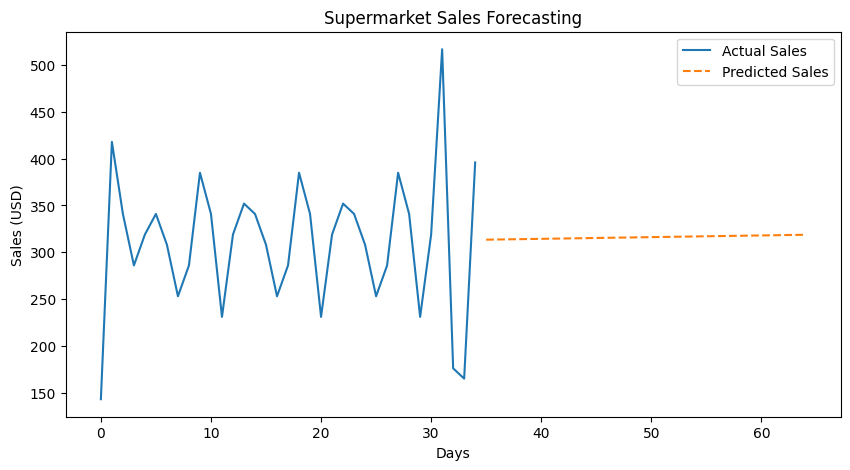

In [19]:
import os
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

model = LinearRegression()
model.fit(X, y)

future_days = np.arange(
    len(sales_data),
    len(sales_data) + 30
).reshape(-1, 1)

future_sales = model.predict(future_days)

print("Predicted Future Sales:")
print(future_sales)

plt.figure(figsize=(10, 5))

plt.plot(
    sales_data['Day_Number'],
    sales_data['Sales'],
    label='Actual Sales'
)

plt.plot(
    future_days,
    future_sales,
    linestyle='--',
    label='Predicted Sales'
)

plt.xlabel("Days")
plt.ylabel("Sales (USD)")
plt.title("Supermarket Sales Forecasting")
plt.legend()

os.makedirs("FUTURE_ML_01/images", exist_ok=True)

plt.savefig("FUTURE_ML_01/images/sales_trend.png")

plt.show()

In [20]:
with open("FUTURE_ML_01/requirements.txt", "w") as f:
    f.write(
        "pandas\n"
        "numpy\n"
        "matplotlib\n"
        "scikit-learn\n"
        "openpyxl\n"
    )

In [22]:
readme_text = """
# Sales & Demand Forecasting using Supermarket Sales Dataset

## Project Overview
This project predicts future sales using Machine Learning techniques based on historical supermarket sales data.

## Dataset
Supermarket Sales Sample Data

## Algorithm Used
Linear Regression

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Openpyxl

## Features
- Data Cleaning
- Sales Trend Analysis
- Sales Forecasting
- Future Sales Prediction

## Output
- Sales forecasting graph
- Future sales prediction for the next 30 days

## Project Structure
FUTURE_ML_01/
│
├── dataset/
│   └── Supermarket-Sales-Sample-Data.xlsx
│
├── images/
│   └── sales_trend.png
│
├── requirements.txt
├── README.md
└── Sales_Demand_Forecasting.ipynb

## Conclusion
The Linear Regression model was trained on historical supermarket sales data to forecast future sales trends and support business decision-making.
"""

with open("FUTURE_ML_01/README.md", "w") as f:
    f.write(readme_text)

